# <span style="color:blue">Workshop 3 example Solution: Multi-objective evolution</span>

Dan Franks: daniel.franks@york.ac.uk

# <span style="color:blue">Learning Objectives</span>

* Implement individuals with different representations to lists
* Implement and then examine multi-objective evolution
* Mu Lambda Evolution

# <span style="color:blue">The problem: the kursawe function</span>

The Kursawe function has two objectives that we will look to minimize. It can have an arbirtarly number of input variables, which take values within the range -5 and 5. Here is the function for the specific case of three inputs:

<img src="equation.png" alt="Kursawe equation" width = 500>

<img src="plot.png" alt="Kursawe plot" width = 500>


There are built-in benchmark problems in DEAP. You import them like this:

In [ ]:
!pip install deap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 KB 7.2 MB/s eta 0:00:00


In [ ]:
from deap import benchmarks

The kursawe function can be called like this:

In [ ]:
exampleInputs = [-5,2,5]
benchmarks.kursawe(exampleInputs)

(-6.812092298638419, 13.935688996486114)

# <span style="color:blue">Exercise 1: Implement a multi objective GA for the kursawe function</span>

Create a GA that gives inputs that minimize the multi-objective function. For this, the number of inputs to use should be 3 to start with. Then try changing it to 5.

## <span style="color:blue">The GA</span>

In [ ]:
from deap import algorithms
from deap import base
from deap import creator
from deap import tools
import random
import numpy

In [ ]:
creator.create("Fitness", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.Fitness)

Note that we are minimizing both objectives (-1.0).

In [ ]:
IND_INIT_SIZE = 3
toolbox = base.Toolbox()
toolbox.register("attr_item", random.uniform, -5.0, 5.0)
toolbox.register("individual", tools.initRepeat, creator.Individual,
    toolbox.attr_item, IND_INIT_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

Our evaluation function is already defined, and so we just register it.

In [ ]:
toolbox.register("evaluate", benchmarks.kursawe)

In [ ]:
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.2, indpb=0.1)
toolbox.register("mate", tools.cxUniform, indpb=0.1)

In [ ]:
def checkBounds(min, max):
    def decorator(func):
        def wrapper(*args, **kargs):
            offspring = func(*args, **kargs)
            for child in offspring:
                for i in range(len(child)):
                    if child[i] > max:
                        child[i] = max
                    elif child[i] < min:
                        child[i] = min
            return offspring
        return wrapper
    return decorator

toolbox.decorate("mutate", checkBounds(-5.0, 5.0))

In [ ]:
toolbox.register("select", tools.selNSGA2)

In [ ]:
inv1 = toolbox.individual()

In [ ]:
print(inv1)

[-3.1862432389116035, -0.039012183538008394, -0.2611767054556342]


In [ ]:
NGEN = 100
popSize = MU = 200
LAMBDA = 400
CXPB = 0.5
MUTPB = 0.5

In [ ]:
def pareto_eq(ind1, ind2):
    return numpy.allclose(ind1[0], ind2[1])

hof = tools.ParetoFront(similar=pareto_eq)

In [ ]:
pop = toolbox.population(n=popSize)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean, axis=0)
stats.register("std", numpy.std, axis=0)
stats.register("min", numpy.min, axis=0)
stats.register("max", numpy.max, axis=0)
logbook = tools.Logbook() #

Using a built-in DEAP GA we can use the Mu plus Lambda algorithm. You can read more about this on the DEAP webpage. This allows us to generate a child population and then select using both parents and child as in the NSGA II algorithm:

In [ ]:
#pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats, halloffame=hof, verbose=False)

OR you can use the fleshed out code. I have implemented a manual Mu plus Lambda code below:

In [ ]:
fitnesses = [toolbox.evaluate(ind) for ind in pop]
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

In [ ]:
for g in range(NGEN):
    print("-- Generation %i --" % g)

    # Generate offspring using VarOr
    offspring = algorithms.varOr(pop, toolbox, LAMBDA, CXPB, MUTPB)
    # Note that the MUTPB is a bit different here. It is the proportion of individuals that will be mutated, rather than crossed over.
    # So with varOr MUTPB + CXPB <= 1.0

    # Evaluate offspring
    invalid_inds = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = [toolbox.evaluate(ind) for ind in invalid_inds]
    for ind, fit in zip(invalid_inds, fitnesses):
        ind.fitness.values = fit

    nextGenOffspring = toolbox.select(pop + offspring, MU)
    nextGenOffspring = list(map(toolbox.clone, nextGenOffspring))
    pop[:] = nextGenOffspring

    hof.update(pop) #This version keeps the HoF a constant size. See also hof.insert()

    record = stats.compile(pop)
    logbook.record(gen=g, **record)

-- Generation 0 --
-- Generation 1 --
-- Generation 2 --
-- Generation 3 --
-- Generation 4 --
-- Generation 5 --
-- Generation 6 --
-- Generation 7 --
-- Generation 8 --
-- Generation 9 --
-- Generation 10 --
-- Generation 11 --
-- Generation 12 --
-- Generation 13 --
-- Generation 14 --
-- Generation 15 --
-- Generation 16 --
-- Generation 17 --
-- Generation 18 --
-- Generation 19 --
-- Generation 20 --
-- Generation 21 --
-- Generation 22 --
-- Generation 23 --
-- Generation 24 --
-- Generation 25 --
-- Generation 26 --
-- Generation 27 --
-- Generation 28 --
-- Generation 29 --
-- Generation 30 --
-- Generation 31 --
-- Generation 32 --
-- Generation 33 --
-- Generation 34 --
-- Generation 35 --
-- Generation 36 --
-- Generation 37 --
-- Generation 38 --
-- Generation 39 --
-- Generation 40 --
-- Generation 41 --
-- Generation 42 --
-- Generation 43 --
-- Generation 44 --
-- Generation 45 --
-- Generation 46 --
-- Generation 47 --
-- Generation 48 --
-- Generation 49 --
-- Generat

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")

In [ ]:
avgs_weight = [item[0] for item in avgs]
avgs_value = [item[1] for item in avgs]

In [ ]:
avgs

[array([-11.99442764,   0.10093914]),
 array([-13.04773722,  -1.83606526]),
 array([-14.20641877,  -3.30018942]),
 array([-15.52767682,  -2.91901556]),
 array([-15.45877611,  -3.96936532]),
 array([-16.1757197 ,  -3.98616824]),
 array([-16.37711177,  -4.35033138]),
 array([-16.62574648,  -4.82691599]),
 array([-16.89882772,  -4.2645643 ]),
 array([-16.91579639,  -4.610569  ]),
 array([-17.18505272,  -4.42392984]),
 array([-17.39958318,  -3.96147818]),
 array([-17.00032839,  -4.98682271]),
 array([-16.88490828,  -5.18000512]),
 array([-16.75639128,  -5.61775089]),
 array([-16.87366739,  -5.32684525]),
 array([-16.87647322,  -5.3531684 ]),
 array([-16.84931132,  -5.39448503]),
 array([-16.76779164,  -5.55435681]),
 array([-16.76290302,  -5.58118491]),
 array([-16.74443123,  -5.59550632]),
 array([-16.76047088,  -5.5777555 ]),
 array([-16.73579943,  -5.66819106]),
 array([-16.79047945,  -5.49507664]),
 array([-16.76156639,  -5.57725024]),
 array([-16.74934639,  -5.62735518]),
 array([-16.

Text(0, 0.5, 'Fitness (weight)')

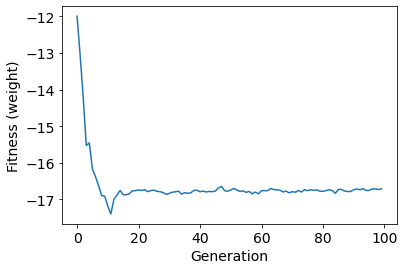

In [ ]:
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)

fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, avgs_weight)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness (weight)")

Text(0, 0.5, 'Fitness (value)')

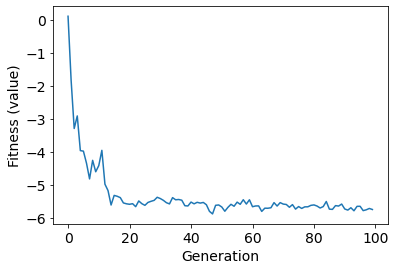

In [ ]:
fig2, ax2 = plt.subplots()
line2 = ax2.plot(gen, avgs_value)
ax2.set_xlabel("Generation")
ax2.set_ylabel("Fitness (value)")

In [ ]:
x = [h[0] for h in hof]
y = [h[1] for h in hof]
z = [h[2] for h in hof]

The code below shows the individuals that make up the Pareto front solutions, in terms of their three input values. This is sometimes useful in visualising which parts of the solution space correspond to Pareto front solutions. In this case, the solutions are clearly clustered.

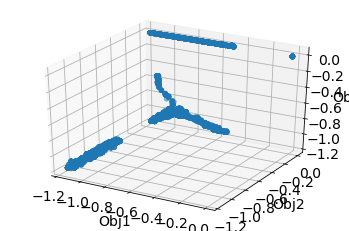

In [ ]:
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.set_xlabel("Obj1")
ax.set_ylabel("Obj2")
ax.set_zlabel("Obj3")
ax.scatter(x, y, z)

The code below shows a Kernel Density Estimation plot - essentially, it shows the regions along the Paretto front where solutions are clustered. In this case, ther eis not much gain from looking at this compared to plotting the solutions as fitness 1 against fitness 2, but in more complex situations it may be useful.

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


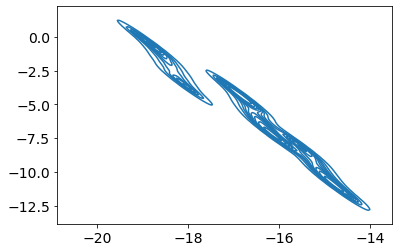

In [ ]:
import seaborn as sns
fitnesses = [x.fitness.values for x in hof]
x = [f[0] for f in fitnesses]
y = [f[1] for f in fitnesses]

sns.kdeplot(x,y)